In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('data/patagonia.csv')
pd.set_option('display.max_columns', None)
import statsmodels.formula.api as smf
display(df.head())
# count nulls
print(df.isnull().sum())

# Each row represents a single customer's data during the 3-week study period. The columns include:
from scipy.stats import ttest_ind
SIGNIFICANCE_LEVEL = 0.05


,age,gender,days_since_last_visit,days_since_last_purchase,num_past_purchases,sales_past_12m,time_on_site_last_visit,time_on_site_12m,email_T,email_touchpoints,youtube_T,youtube_touchpoints,instagram_T,instagram_touchpoints,google_search_T,google_search_touchpoints,contextual_display_T,contextual_display_touchpoints,sales,touchpoint_sequence,first_touch,last_touch
0,29,Female,4.69,7.91,0,120.13,4.35,98.08,1,1,0,0,0,0,0,0,1,1,0.0,"email,contextual_display",email,contextual_display
1,41,Female,30.10,40.73,1,77.30,13.28,28.90,1,0,1,0,1,0,1,1,1,1,0.0,"contextual_display,google_search",contextual_display,google_search
2,41,Female,13.17,43.53,1,191.70,1.26,140.37,1,0,0,0,1,2,0,0,1,0,0.0,"instagram,instagram",instagram,instagram
3,46,Male,9.13,26.29,3,202.73,0.07,60.51,0,0,1,0,1,1,1,0,1,1,0.0,"contextual_display,instagram",contextual_display,instagram
4,50,Male,1.70,9.17,1,136.06,15.41,23.76,1,1,1,0,0,0,0,0,1,0,0.0,email,email,email


age                                    0
gender                                 0
days_since_last_visit                  0
days_since_last_purchase               0
num_past_purchases                     0
sales_past_12m                         0
time_on_site_last_visit                0
time_on_site_12m                       0
email_T                                0
email_touchpoints                      0
youtube_T                              0
youtube_touchpoints                    0
instagram_T                            0
instagram_touchpoints                  0
google_search_T                        0
google_search_touchpoints              0
contextual_display_T                   0
contextual_display_touchpoints         0
sales                                  0
touchpoint_sequence               361424
first_touch                       361424
last_touch                        361424
dtype: int64


In [2]:
display(df.describe())
# Why is the there negative sales? Is it returns? Let's see how many rows have negative sales.
print("Number of rows with negative sales: ", (df['sales'] < 0).sum())
# Let's see the distribution of sales for these rows with negative sales.
print(df[df['sales'] < 0]['sales'].describe())

,age,days_since_last_visit,days_since_last_purchase,num_past_purchases,sales_past_12m,time_on_site_last_visit,time_on_site_12m,email_T,email_touchpoints,youtube_T,youtube_touchpoints,instagram_T,instagram_touchpoints,google_search_T,google_search_touchpoints,contextual_display_T,contextual_display_touchpoints,sales
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,3.450744e+01,9.997817e+00,4.001595e+01,2.000182e+00,9.996832e+01,5.005528e+00,6.004675e+01,7.998745e-01,2.844265e-01,7.995740e-01,1.944460e-01,8.005035e-01,2.509680e-01,7.998670e-01,2.012840e-01,7.996310e-01,1.049534e+00,8.703738e-01
std,9.996875e+00,1.000388e+01,3.163188e+01,1.414640e+00,7.069700e+01,5.003620e+00,4.247837e+01,4.000942e-01,5.688288e-01,4.003192e-01,4.671465e-01,3.996220e-01,5.417446e-01,4.000998e-01,4.753850e-01,4.002766e-01,1.127631e+00,8.494020e+00
min,-1.300000e+01,0.000000e+00,3.000000e-02,0.000000e+00,4.000000e-02,0.000000e+00,2.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.593000e+01
25%,2.800000e+01,2.880000e+00,1.751000e+01,1.000000e+00,4.803000e+01,1.440000e+00,2.883000e+01,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
50%,3.500000e+01,6.930000e+00,3.173000e+01,2.000000e+00,8.395000e+01,3.470000e+00,5.036000e+01,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
75%,4.100000e+01,1.385000e+01,5.349000e+01,3.000000e+00,1.345600e+02,6.950000e+00,8.084000e+01,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00
max,8.700000e+01,1.429700e+02,4.799800e+02,1.200000e+01,7.882100e+02,7.303000e+01,5.717400e+02,1.000000e+00,5.000000e+00,1.000000e+00,5.000000e+00,1.000000e+00,6.000000e+00,1.000000e+00,5.000000e+00,1.000000e+00,7.000000e+00,3.860400e+02


Number of rows with negative sales:  13
count    13.000000
mean     -3.853077
std       4.667880
min     -15.930000
25%      -5.310000
50%      -1.810000
75%      -0.860000
max      -0.210000
Name: sales, dtype: float64


# Question 1: Attribution Without Incrementality

## a. Last-Touch Attribution Model

Compute the total sales attributed to each channel using the last-touch attribution model. In this model, 100% of a customer's sale (if any) is attributed to the last marketing channel they interacted with prior to conversion.

In [3]:
# Group by last_touch and aggregate by sum of sales, count, and mean of sales, and sales per customer
grouped_last_touch = df.groupby('last_touch').agg({'sales': ['sum', 'count', 'mean']})
grouped_last_touch.columns = ['total_sales', 'customer_count', 'average_sales']
display(grouped_last_touch)

# df['last_touch'] = df['last_touch'].fillna('none')
# There are customers with no last touch, which means they had no touchpoints. 
# We can fill these with 'none' to make it easier to analyze.
# It's commented out since its not in scope for this homework, but its something to keep in mind:
# Some customers had zero exposure and still had sales!

,total_sales,customer_count,average_sales
last_touch,,,
contextual_display,544429.67,706367,0.770746
email,103145.35,110611,0.932505
google_search,369960.84,341061,1.084735
instagram,321662.74,335439,0.958931
youtube,139685.87,145098,0.962700


## b. First-Touch Attribution Model

Repeat the process using the first-touch attribution model, where 100% of the sale is attributed to the first marketing channel the customer encountered during the study period.

In [4]:
# Group by first_touch and aggregate by sum of sales, count, and mean of sales, and sales per customer
grouped_first_touch = df.groupby('first_touch').agg({'sales': ['sum', 'count', 'mean']})
grouped_first_touch.columns = ['total_sales', 'customer_count', 'average_sales']
display(grouped_first_touch)

# df['first_touch'] = df['first_touch'].fillna('none')
# Commented out, same logic as last touch, some customers had zero exposure and still had sales!

,total_sales,customer_count,average_sales
first_touch,,,
contextual_display,665682.69,826637,0.805290
email,471100.59,455894,1.033356
google_search,73610.06,74544,0.987471
instagram,101525.20,111397,0.911382
youtube,166965.93,170104,0.981552


## c. Linear Attribution Model

Compute sales attribution using the linear attribution model. In this model, a customer's sale is split across all the channels that touched them prior to conversion, with credit assigned to each channel proportional to the number of touches it contributed. For example, if a customer received 2 touches from email and 1 from YouTube before converting, then 2/3 of their sale would be attributed to email and 1/3 to YouTube.

In [5]:
## c) Linear Attribution
# First, we calculate the total number of touchpoints for each customer
df['total_touchpoints'] = df['contextual_display_touchpoints'] + df['email_touchpoints'] + df['instagram_touchpoints'] + df['google_search_touchpoints']+ df['youtube_touchpoints']

# Then, for each customer and each channel, we calculate the linear attributed sales
# % of their sales coming from that channel
# weight each sale to their channels
df['email_linear_sales'] = df['email_touchpoints'] / df['total_touchpoints'] * df['sales']
df['google_search_linear_sales'] = df['google_search_touchpoints'] / df['total_touchpoints'] * df['sales']
df['youtube_linear_sales'] = df['youtube_touchpoints'] / df['total_touchpoints'] * df['sales']
df['instagram_linear_sales'] = df['instagram_touchpoints'] / df['total_touchpoints'] * df['sales']
df['contextual_display_linear_sales'] = df['contextual_display_touchpoints'] / df['total_touchpoints'] * df['sales']

# for customers that had no touchpoints, their sales go under none_linear_sales
# df['none_linear_sales'] = np.where(df['total_touchpoints'] == 0, df['sales'],0)

# weight the customers to their channels. % of a customer coming from that channel
df['email_linear_customers'] = df['email_touchpoints'] / df['total_touchpoints'] 
df['google_search_linear_customers'] = df['google_search_touchpoints'] / df['total_touchpoints']
df['youtube_linear_customers'] = df['youtube_touchpoints'] / df['total_touchpoints']
df['instagram_linear_customers'] = df['instagram_touchpoints'] / df['total_touchpoints']
df['contextual_display_linear_customers'] = df['contextual_display_touchpoints'] / df['total_touchpoints']

# df['none_linear_customers'] = np.where(df['total_touchpoints'] == 0, 1,0)
# every sale is now weighted to the channel that helped create it. 

# Finally, we create a new data frame to store the results in
attribution_linear = pd.DataFrame(columns=['channel', 'attributed_sales', 'attributed_customers'])
attribution_linear.loc[len(attribution_linear)]= ['email', df['email_linear_sales'].sum(), df['email_linear_customers'].sum()]
attribution_linear.loc[len(attribution_linear)]= ['google_search', df['google_search_linear_sales'].sum(), df['google_search_linear_customers'].sum()]
attribution_linear.loc[len(attribution_linear)]= ['youtube', df['youtube_linear_sales'].sum(), df['youtube_linear_customers'].sum()]
attribution_linear.loc[len(attribution_linear)]= ['instagram', df['instagram_linear_sales'].sum(), df['instagram_linear_customers'].sum()]
attribution_linear.loc[len(attribution_linear)]= ['contextual_display', df['contextual_display_linear_sales'].sum(), df['contextual_display_linear_customers'].sum()]
# attribution_linear.loc[len(attribution_linear)]= ['none', df['none_linear_sales'].sum(), df['none_linear_customers'].sum()]
# Create none channel for customers with no touchpoints. A sale is attributed to none if the customer had no touchpoints.
attribution_linear['average_sales_per_customer'] = attribution_linear['attributed_sales'] / attribution_linear['attributed_customers']
print("Linear Attribution Results:")
display(attribution_linear)
print()
unaccounted_sales = df.sales.sum() - attribution_linear.attributed_sales.sum()
print(f"Unaccounted sales: ${unaccounted_sales:,.2f} are from customers with zero touchpoints, who cannot be attributed across channels under the linear attribution model")

# Create a model_tracker dataframe that tracks each channel, with columns of attributed sales from each model
model_tracker = pd.DataFrame()
# Lets start with channel, first_touch_attributed_sales, last_touch_attributed_sales, linear_attributed_sales
model_tracker['channel'] = attribution_linear['channel']

# Make sure the order of channels in grouped_first_touch and grouped_last_touch matches the order in attribution_linear
# We can do this by reindexing grouped_first_touch and grouped_last_touch to match the order of channels in attribution_linear
grouped_first_touch = grouped_first_touch.reindex(attribution_linear['channel'])
grouped_last_touch = grouped_last_touch.reindex(attribution_linear['channel'])
model_tracker['last_touch_attributed_sales'] = grouped_last_touch['total_sales'].values

model_tracker['first_touch_attributed_sales'] = grouped_first_touch['total_sales'].values
model_tracker['linear_attributed_sales'] = attribution_linear['attributed_sales'].values


Linear Attribution Results:


,channel,attributed_sales,attributed_customers,average_sales_per_customer
0,email,247005.997488,245961.261003,1.004248
1,google_search,184189.761079,174575.584019,1.055072
2,youtube,169430.220520,168886.145779,1.003222
3,instagram,202724.217778,213221.361797,0.950769
4,contextual_display,675534.273135,835931.647403,0.808121



Unaccounted sales: $261,863.19 are from customers with zero touchpoints, who cannot be attributed across channels under the linear attribution model


## d. Comparison of Attribution Models

Briefly compare the results of the three attribution models. Which channels appear more or less effective depending on the model used? What do these differences reveal about the assumptions underlying each model? What risks might Patagonia face if it relies on one of these approaches to guide marketing investment?

In [6]:
model_tracker

,channel,last_touch_attributed_sales,first_touch_attributed_sales,linear_attributed_sales
0,email,103145.35,471100.59,247005.997488
1,google_search,369960.84,73610.06,184189.761079
2,youtube,139685.87,166965.93,169430.220520
3,instagram,321662.74,101525.20,202724.217778
4,contextual_display,544429.67,665682.69,675534.273135


*Note: Excludes "none" channel since technically not a channel, and we are interested in understanding the impact of marketing channels on sales.*

As we can see, the results are highly sensitive to the model we choose. For example, email gets $247K in linear attribution, $471K in first-touch attribution, and $103K in last-touch attribution It is very hard to make any conclusion when we have so much variation in the results depending on the model we choose. In other words, it's not the data telling us what to do, we are deciding what to do by choosing a model. 

The most effective channels (as measured by attributed sales) were as follows:
- Last-touch attribution: contextual display, email, and google search
- First-touch attribution: email, google search, and contextual display
- Linear attribution: email, google search, and contextual display

If measured by sales per customer:
- Last-touch attribution: contextual display, email, and google search
- First-touch attribution: email, google search, and contextual display
- Linear attribution: contextual display, email, and google search

Assumptions of last touch attribution: the last channel is the most influential in driving the sale. This may not be true if the customer had multiple touchpoints and the last one was just a reminder.

Assumptions of first touch attribution: the first channel is the most influential in driving the sale. This may not be true if the customer had multiple touchpoints and the first one was just an introduction.

Assumptions of linear attribution: all channels and touchpoints contribute equally to the sale. This may not be true if some channels are more influential than others.

If patagonia relies on one of these approaches to guide marketing investment, they may overinvest in channels that appear more effective under that model, while underinvesting in channels that are actually driving sales but don't get credit under that model.

As is, we don't know which model is correct, so we should be cautious in interpreting the results. Additionally analysis later on will help us understand which channels are actually driving incremental sales, which will be more informative for guiding marketing investment.

# Question 2: Estimating Incremental Sales with Experimental Data

## a. Intent-to-Treat (ITT) Effect

For each channel, compute the Intent-to-Treat (ITT) effect by comparing the average sales of customers in the treatment group to those in the holdout group. Report the difference in means for each channel.

In [7]:
# is anyones sum of channel_T = 0?
df['is_no_touchpoints'] = df['total_touchpoints'] == 0 # Binary variable indicating if a customer had no touchpoints

# For each channel, get average sales in 1) Treatment 2) Holdout. Report difference in means.
channels = ['email', 'google_search', 'youtube', 'instagram', 'contextual_display']
itt_estimates = {}

itt_tracker = pd.DataFrame(columns=['channel', 'treatment_mean_sales', 'holdout_mean_sales', 'ITT_estimate (diff in means)', 'p_value', 'significant at 0.05 level','in_treatment', 'in_control', 'touchpoints'])

# Rewrite to also show 95% confidence intervals
for channel in channels:
    # Column channel_T == 1 is treatment, channel_T == 0 is holdout
    treatment_sales = df[df[f'{channel}_T'] == 1]['sales']
    holdout_sales = df[df[f'{channel}_T'] == 0]['sales']
    mean_diff = treatment_sales.mean() - holdout_sales.mean()
    itt_estimates[channel] = mean_diff
    # Sum of the channel_T column gives us the number of customers in treatment, and the rest are in control
    in_treatment = df[f'{channel}_T'].sum()
    touchpoints = df[f'{channel}_touchpoints'].sum()
    in_control = len(df) - in_treatment
    itt_tracker.loc[len(itt_tracker)] = [channel, treatment_sales.mean(), holdout_sales.mean(), mean_diff, ttest_ind(holdout_sales, treatment_sales)[1], ttest_ind(holdout_sales, treatment_sales)[1] < SIGNIFICANCE_LEVEL, in_treatment, in_control, touchpoints]

# now do the "none" channel since they're a bit different. Commented out since we are looking at each channel independetly (not order and combinations), "none" is not a channel but rather than absence of all channels.
# treatment_sales = df[df['is_no_touchpoints'] == 1]['sales']
# holdout_sales = df[df['is_no_touchpoints'] == 0]['sales']
# mean_diff = treatment_sales.mean() - holdout_sales.mean()
# itt_estimates['none'] = mean_diff
# in_treatment['none'] = df['is_no_touchpoints'].sum()
# in_control['none'] = len(df) - in_treatment['none']
# tracker.loc[len(tracker)] = ['none', treatment_sales.mean(), holdout_sales.mean(), mean_diff, ttest_ind(holdout_sales, treatment_sales)[1], ttest_ind(holdout_sales, treatment_sales)[1] < SIGNIFICANCE_LEVEL]

itt_tracker[['channel', 'ITT_estimate (diff in means)', 'p_value', 'significant at 0.05 level','in_treatment', 'in_control', 'touchpoints']]

,channel,ITT_estimate (diff in means),p_value,significant at 0.05 level,in_treatment,in_control,touchpoints
0,email,0.069603,0.000004,True,1599749,400251,568853
1,google_search,0.036539,0.014931,True,1599734,400266,402568
2,youtube,0.071726,0.000002,True,1599148,400852,388892
3,instagram,0.045620,0.002403,True,1601007,398993,501936
4,contextual_display,0.017477,0.244129,False,1599262,400738,2099068


## b. Total Incremental Sales

Multiply each channel's ITT estimate by the number of customers in the treatment group for that channel. This gives you the total incremental sales that can be causally attributed to each channel during the experiment. Report these totals.

In [8]:
itt_tracker['incremental_sales'] = itt_tracker['ITT_estimate (diff in means)'] * itt_tracker['in_treatment']
itt_tracker[['channel', 'incremental_sales' , 'ITT_estimate (diff in means)', 'in_treatment']]


,channel,incremental_sales,ITT_estimate (diff in means),in_treatment
0,email,111348.008281,0.069603,1599749
1,google_search,58453.035925,0.036539,1599734
2,youtube,114700.141215,0.071726,1599148
3,instagram,73037.198914,0.045620,1601007
4,contextual_display,27950.071551,0.017477,1599262


## c. Comparison to Question 1 Results

Compare your results to those from Question 1. Which channels received more or less credit under the naive attribution models than they did based on experimental evidence? What does this reveal about the limitations of last-touch, first-touch, and linear attribution?

In [9]:
model_tracker['ITT Sales Attribution'] = model_tracker['channel'].map(itt_tracker.set_index('channel')['incremental_sales'])
display(model_tracker)

print("Total sales attributed to channels under each approach:")
print(model_tracker.drop(columns=['channel']).sum().round())

,channel,last_touch_attributed_sales,first_touch_attributed_sales,linear_attributed_sales,ITT Sales Attribution
0,email,103145.35,471100.59,247005.997488,111348.008281
1,google_search,369960.84,73610.06,184189.761079,58453.035925
2,youtube,139685.87,166965.93,169430.220520,114700.141215
3,instagram,321662.74,101525.20,202724.217778,73037.198914
4,contextual_display,544429.67,665682.69,675534.273135,27950.071551


Total sales attributed to channels under each approach:
last_touch_attributed_sales     1478884.0
first_touch_attributed_sales    1478884.0
linear_attributed_sales         1478884.0
ITT Sales Attribution            385488.0
dtype: float64


There are a few important observations to make.
First, the incremental numbers are much smaller on average than any of the last- first- or linear touch attribution models
display rounded numbers for easier comparison

In particular, the total amount of sales attributed to these 5 channels is $385K if we use an incremental approach
If we use any of the naive approaches, the sales attributed to these 5 channels will be $1.48M (roughly 4x larger)

The ITT attributed less sales to channels than the other 3 (which were all equal) because the gap is the sales unattributable to channels.

In [10]:
itt_tracker[['channel','touchpoints']]

,channel,touchpoints
0,email,568853
1,google_search,402568
2,youtube,388892
3,instagram,501936
4,contextual_display,2099068


Contextual Display happens to touch a large fraction of customers.
This is partly because static display ads are relatively cheaper than the other channels in our case
More importantly, when evaluating the impact of display ads, we typically use "view-through" attribution
In other words, as long as a customer is exposed to the ad (even if the ad is not clicked) we may attribute the sales to the ad
In contrast, for search ads, the ad has to be clicked for being able to get attribution credit (i.e., we use "click-through" attribution)
Since the bar is lower (i.e., it's easier) for us to attribute sales to contextual display, those ads just end up receiving a lot of credit
Not because they're *increasing sales*, but because they just "touch" a lot of customers and some of those customers end up converting

We still don't know how order of touchpoints impacts sales, but we do know that the incremental approach gives us a more accurate estimate of the true contribution of each channel to sales, which is crucial for making informed marketing investment decisions.

Another difference is the ITT analysis is per channel whereas the attribution models are per customer. This means that the ITT analysis is looking at the average effect of being in the treatment group for each channel, while the attribution models are looking at the contribution of each channel to each customer's sale.

### Supplements & Scratch Work (Disregard for Grading)

All channels received less credit under the incremental approach than they did under the naive attribution models. For example, email received $103K in incremental sales, but $471K in first-touch attribution and $247K in linear attribution. This reveals that the naive attribution models are likely overestimating the contribution of these channels to sales, because they are not accounting for the fact that some of the sales would have happened even without those channels (i.e. they are not incremental). The incremental approach gives us a more accurate estimate of the true impact of each channel on sales, which is crucial for making informed marketing investment decisions. 

How is the incremental adding controls for other factors when it looks like its just comparing the treatment and holdout groups? The key is that the treatment and holdout groups are randomly assigned, which means that on average, they should be similar in terms of other factors that could influence sales (e.g. customer demographics, seasonality, etc.). 



#### Randomization Check

In [11]:
# Are the treatment and holdout groups randomly assigned? Age, gender ,etc. We do this for each channel.
# Change gender to 0/1
df['gender_binary'] = np.where(df['gender'] == 'Male', 1, 0)

channels = ['email', 'google_search', 'youtube', 'instagram', 'contextual_display']
baseline_vars = ['days_since_last_visit', 'days_since_last_purchase', 'age', 'num_past_purchases',
                 'sales_past_12m', 'time_on_site_12m', 'gender_binary']

treatment_indicators = [f'{c}_T' for c in channels]
touchpoint_counts = [f'{c}_touchpoints' for c in channels]
number_of_tests = 0
for channel in channels:
    # Exclude the channel being checked from the covariate list
    
    other_treatments = [c for c in treatment_indicators if c != f'{channel}_T']
    other_touchpoints = [c for c in touchpoint_counts if c != f'{channel}_touchpoints']
    to_check = baseline_vars + other_treatments + other_touchpoints

    for col in to_check:
        treatment_group = df[df[f'{channel}_T'] == 1][col]
        holdout_group = df[df[f'{channel}_T'] == 0][col]
        t_stat, p_value = ttest_ind(treatment_group, holdout_group)
        if p_value < SIGNIFICANCE_LEVEL:
            print(f"Non-random assignment detected for {channel} channel: {col}")
            print(f"T-statistic: {t_stat}, P-value: {p_value}")
            print("\n")
        number_of_tests += 1
print(f"Total number of tests conducted: {number_of_tests}")

Non-random assignment detected for google_search channel: contextual_display_touchpoints
T-statistic: 2.212666318499033, P-value: 0.026920771641892965


Non-random assignment detected for instagram channel: youtube_touchpoints
T-statistic: -2.027996107433106, P-value: 0.042560777566899036


Non-random assignment detected for contextual_display channel: days_since_last_visit
T-statistic: -2.1530190688918673, P-value: 0.03131729911334429


Total number of tests conducted: 75


We found 3 "violations" at α = 0.05 out of 75 tests. With 75 tests, expect ~3.75 false positives by chance at this alpha (75 x 0.05). So our 3 "violations" is still within our expectation under random assignment, so we can still be reasonably confident in the randomization of the experiment overall. This is called the bonferroni correction, which is a method to adjust for multiple comparisons and control the family-wise error rate.

Regardless, because we have detected non-random assignment for some channels, we should be cautious in interpreting the results of the incremental analysis. For example, in groups that were and were not exposed to google_search, the 2 groups had differnt exposures to contextual_display_touchpoints. The difference we observe from the incremental analysis may be due to the fact that the exposure to contextual_display_touchpoints.

Also, since its ITT, just because someone is in treatment for a channel doesn't mean they were actually exposed to that channel. 



#### Additional Notes & Visuals to help understanding 

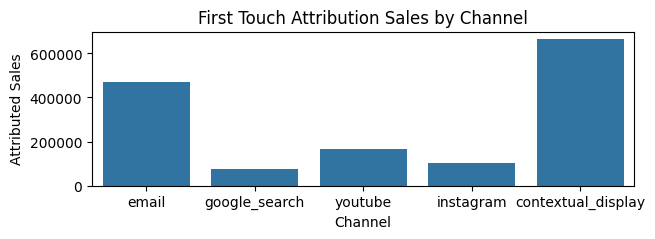

In [12]:
# Bar Chart of Naive Attributions.
# Theres zero notion of control/treatment here. No "knob being turned"
import seaborn as sns
import matplotlib.pyplot as plt

# First Touch Attribution
plt.figure(figsize=(7, 2))
sns.barplot(x='channel', y='total_sales', data=grouped_first_touch.reset_index())
plt.title('First Touch Attribution Sales by Channel')
plt.ylabel('Attributed Sales')
plt.xlabel('Channel')
plt.show()


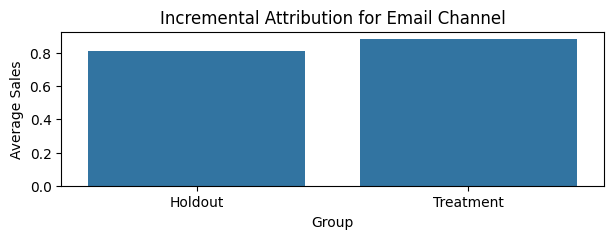

In [13]:
# Incremental Attribution
# Incremental is per channel, sicne thats what we are interested in determining causal impact of.
# So lets just do this for a single channel, email.

# Bar chart for just email. 2 bars, one for treatment and one for holdout.
plt.figure(figsize=(7, 2))
# Side by side, not stacked. 

temporary_group_by = df.groupby('email_T').agg({'sales': 'mean'}).reset_index()
temporary_group_by['email_T'] = temporary_group_by['email_T'].map({0: 'Holdout', 1: 'Treatment'})
sns.barplot(x='email_T', y='sales', data=temporary_group_by)     
plt.title('Incremental Attribution for Email Channel')
plt.ylabel('Average Sales')
plt.xlabel('Group')
plt.show()

# That gap between the 2 bars. is the impact of the treatment. On the average sales of a customer.
# This is still imperfect
# 1. ITT is intent, so just because someone is in treatment doesn't mean they were actually treated. 

# 2. It assumes perfect randomization so the difference is not due to other factors. We did some tests for this above. 
# 3. It assumes no leakage of exposure. For example, a person in holdout group for 
# youtube ads might be at a friends house and see the youtube ad on their friend's computer, 
# which would contaminate the holdout group.

# 4. We still can't pinpoint funnel effects and order of touchpoints. For example, maybe email is more effective if its 
# the first touchpoint, but not as effective if its the last touchpoint. We can't see this with ITT since we're looking at each channel independently.


## d. Organic Sales Estimation

Estimate the number of sales that would have occurred during the study period even if Patagonia had turned off all five marketing channels. In other words, what is your estimate of total organic sales—sales not causally attributable to any of the five channels? Explain how you arrived at this number using the experimental data. Then, consider how this question would be answered using naive attribution models. What would those models implicitly assume about the number of organic sales?

In [14]:
# We subtract the total incremental sales from total sales to remove the incremental sales attributed 
# to channels, to get the estimated sales from experimental organic (no exposure to channels).
print(f"Estimated sales from experimental organic (no exposure to channels): ${df.sales.sum()- itt_tracker.incremental_sales.sum():,.2f}")

organic_sales_naive_last_touchpoint = df.sales.sum() - grouped_last_touch['total_sales'].sum()
organic_sales_naive_first_touchpoint = df.sales.sum() - grouped_first_touch['total_sales'].sum()
organic_sales_naive_linear = df.sales.sum() - attribution_linear['attributed_sales'].sum()
print(f"Estimated sales from experimental organic (no exposure to channels) using last touchpoint: ${organic_sales_naive_last_touchpoint:,.2f}")
print(f"Estimated sales from experimental organic (no exposure to channels) using first touchpoint: ${organic_sales_naive_first_touchpoint:,.2f}")
print(f"Estimated sales from experimental organic (no exposure to channels) using linear attribution: ${organic_sales_naive_linear:,.2f}")

Estimated sales from experimental organic (no exposure to channels): $1,355,259.20
Estimated sales from experimental organic (no exposure to channels) using last touchpoint: $261,863.19
Estimated sales from experimental organic (no exposure to channels) using first touchpoint: $261,863.19
Estimated sales from experimental organic (no exposure to channels) using linear attribution: $261,863.19


Experimental Data:
- Subtracted total atributed sales from total sales to get estimated organic sales
- Logic is without sales attributed to a channel, the leftover sales must be from organic (no exposure to channels)

Naive Data:
- Subtracted total atributed sales from total sales to get estimated organic sales.
- Difference here is that attributed sales are much higher in the naive data, so the estimated organic sales will be much lower. This is because the naive attribution models are overestimating the contribution of these channels to sales, which means they are underestimating the number of organic sales.

### Scratch Work and Experimental Organic Sales Estimation (Disregard for Grading)

In [32]:
# Alternatively, as a regression model. Will do in next question but it came up as I was doing this. 
# Playing around with this, but does not give same estimate as experimental organic which is correct per markscheme.
# which is interesting and something to think about.

# It seems more correct to me, since the incremental sales above believes its the impact of being in treatment
# for that channel. But they can also be in treatment for other channels!
# Although... we did a randomization check above and they seem to be randomly assigned, 
# so being in treatment for one channel shouldn't mean you're more likely to be in treatment for another channel. 
# So maybe this regression approach is also valid?
# The approach above assumes zero overlap between channels, so we can just look at each channel independently. 
# Which we can! Since 
model = smf.ols(formula = 'sales ~ email_T + youtube_T + instagram_T + google_search_T + contextual_display_T ',data=df).fit()
print(model.params)

# The coefs here are the same as the ITT estimates. 
# These coefs are the impact on sales upon being treated with its respective channel.
# The intercept is the impact on sales when all others are 0.

# If all channels turned off, the intercept x number of customers, is the total sales estimate
experimental_organic_sales_regression = model.params['Intercept'] * len(df)
print()
print(f"Estimated sales from experimental organic (no exposure to channels): ${experimental_organic_sales_regression:,.2f}")


Intercept               0.677794
email_T                 0.069574
youtube_T               0.071706
instagram_T             0.045615
google_search_T         0.036520
contextual_display_T    0.017344
dtype: float64

Estimated sales from experimental organic (no exposure to channels): $1,355,588.62


In [34]:
# This is quite different than if we do an organic estimation. 
# Subtracting the incremental sales from total sales to get experimental organic gave us:
experimental_organic_sales_estimation = df.sales.sum() - itt_tracker.incremental_sales.sum()
experimental_organic_sales_estimation - experimental_organic_sales_regression
# The Regression one is slightly higher. 

-329.4145415376406

In [37]:
# Is it from the difference between the coefficients and the ITT estimates? Maybe, they seem small but over times it can add up.
# Lets check. 
# We'll use the regression coefficients in place of the ITT estimates to get incremental sales. 
# The result of subtracting this from total should get us the same as out experimental_organic_sales_estimation
# If it doesnt then its likely something else. 

# Lets do each coefficient x number of customers in treatment for that channel, to get the incremental sales attributed to that channel.
incremental_sales_email = model.params['email_T'] * df['email_T'].sum()
incremental_sales_youtube = model.params['youtube_T'] * df['youtube_T'].sum()
incremental_sales_instagram = model.params['instagram_T'] * df['instagram_T'].sum()
incremental_sales_google_search = model.params['google_search_T'] * df['google_search_T'].sum()
incremental_sales_contextual_display = model.params['contextual_display_T'] * df['contextual_display_T'].sum()
print()

# Compared to attributed effect from non regression approach
print(f"Total Incremental Sales: ${incremental_sales_email + incremental_sales_youtube + incremental_sales_instagram + incremental_sales_google_search + incremental_sales_contextual_display:,}")
print(f"Organic Sales: ${df.sales.sum() - (incremental_sales_email + incremental_sales_youtube + incremental_sales_instagram + incremental_sales_google_search + incremental_sales_contextual_display):,}")


Total Incremental Sales: $385,159.0413444504
Organic Sales: $1,355,588.6186555494


In [40]:
experimental_organic_sales_regression 

print(f"Subtract ITT incremental sales from total: ${experimental_organic_sales_estimation:,.2f}")
print(f"Using intercept of regression: ${experimental_organic_sales_regression:,.2f}")
print(f"Using regression coefficients in-place of ITT (small difference): ${experimental_organic_sales_regression:,.2f}")

Subtract ITT incremental sales from total: $1,355,259.20
Using intercept of regression: $1,355,588.62
Using regression coefficients in-place of ITT (small difference): $1,355,588.62


In [ ]:
# They are the same! 
# Using regression coeffs in-place of ITT gives same organic sales estimate as intercept of regression!
# So the ITT organic sales is off because the ITT estimates are slightly different than the regression coefficients, which we can see above.

## e. Risks of Naive Attribution

Based on your analysis, what do you conclude about the risks of relying solely on naive attribution to assess marketing performance or justify marketing spend?

If we do proper incremental analysis, we conclude that $1.35M of our sales would've happened without any of the 5 channels

The naive models tell us that if we turn of the 5 channels, our sales would be only $262K

Note that both models are pointing to the *short-term* impact of our marketing. 

In other words, the naive attribution models vastly overestimate the impact of marketing activities
For example, in reality, a lot of our sales come from the fact that customers have been satisfied with our service or products in the past

Those customers would've bought from us regardless of our marketing activities

But naive attribution models do not give enough credit to non-marketing efforts

# Question 3: Estimating Incremental Impact Using Regression

## a. Regression-Based Impact Estimation

Use a regression framework to estimate the impact of each channel on customer sales. Use the treatment indicators (e.g., email_T, youtube_T, etc.) as your primary independent variables. What are the estimated coefficients for each channel? How do they compare to the ITT estimates from Question 2? 

*Hint: Think of this as an alternative way to estimate incremental effects, adjusting for overlap across channels. You do not need to model touchpoint intensity—only treatment assignment.*

In [17]:
model = smf.ols(formula = 'sales ~ email_T + youtube_T + instagram_T + google_search_T + contextual_display_T ',data=df).fit()
print("Regression Coefficients from OLS model:")
display(model.summary())
print()
print("ITT Estimates from Q2:")
itt_tracker[['channel', 'ITT_estimate (diff in means)', 'p_value']]

Regression Coefficients from OLS model:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     12.16
Date:                Sat, 21 Feb 2026   Prob (F-statistic):           8.24e-12
Time:                        18:11:57   Log-Likelihood:            -7.1166e+06
No. Observations:             2000000   AIC:                         1.423e+07
Df Residuals:                 1999994   BIC:                         1.423e+07
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.6778      0.027     24.647      0.000       0.624       0.732
email_T                  0.0696      0.015      4.635      0.000       0.040       0.099
youtube_T                0.0717      0.015      4.779      0.000       0.042       0.101
instagram_T              0.0456      0.015      3.035      0.002       0.016       0.075
google_search_T          0.0365      0.015      2.433      0.015       0.007       0.066
contextual_display_T     0.0173      0.015      1.156      0.248      -0.012       0.047
==============================================================================
Omnibus:                  3558397.184   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):       4108285483.370
Skew:                          13.022   Prob(JB):                         0.00
Kurtosis:                     223.502   Cond. No.                         10.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


ITT Estimates from Q2:


,channel,ITT_estimate (diff in means),p_value
0,email,0.069603,0.000004
1,google_search,0.036539,0.014931
2,youtube,0.071726,0.000002
3,instagram,0.045620,0.002403
4,contextual_display,0.017477,0.244129


The results are very close to what we got in Q2; the slightly difference is because the regression looks at everything jointly




## b. Impact of Control Variables

Consider extending your regression by including control variables such as customer demographics or past behavior (e.g., age, gender, number of past purchases, recent site activity). What happens to your estimates when these controls are added? Why might this adjustment be useful?

In [18]:
controls = ['days_since_last_visit', 'days_since_last_purchase', 'age', 'num_past_purchases',
                 'sales_past_12m', 'time_on_site_12m', 'C(gender)']
base_formula = 'sales ~ email_T + youtube_T + instagram_T + google_search_T + contextual_display_T '
controls_formula = base_formula + ' + ' + ' + '.join(controls)
model_with_controls = smf.ols(formula = controls_formula, data=df).fit()
print("Regression Coefficients from OLS model with controls:")
display(model_with_controls.summary())

Regression Coefficients from OLS model with controls:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     313.0
Date:                Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:12:01   Log-Likelihood:            -7.1147e+06
No. Observations:             2000000   AIC:                         1.423e+07
Df Residuals:                 1999987   BIC:                         1.423e+07
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    0.1124      0.039      2.894      0.004       0.036       0.189
C(gender)[T.Male]           -0.0119      0.012     -0.990      0.322      -0.035       0.012
email_T                      0.0709      0.015      4.728      0.000       0.042       0.100
youtube_T                    0.0725      0.015      4.837      0.000       0.043       0.102
instagram_T                  0.0454      0.015      3.025      0.002       0.016       0.075
google_search_T              0.0364      0.015      2.426      0.015       0.007       0.066
contextual_display_T         0.0170      0.015      1.131      0.258      -0.012       0.046
days_since_last_visit       -0.0008      0.001     -1.302      0.193      -0.002       0.000
days_since_last_purchase     0.0030      0.000     15.009      0.000       0.003       0.003
age                      -8.156e-05      0.001     -0.136      0.892      -0.001       0.001
num_past_purchases          -0.0582      0.004    -13.722      0.000      -0.067      -0.050
sales_past_12m               0.0047   8.49e-05     55.834      0.000       0.005       0.005
time_on_site_12m             0.0017      0.000     12.237      0.000       0.001       0.002
==============================================================================
Omnibus:                  3547263.785   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):       4018131486.068
Skew:                          12.940   Prob(JB):                         0.00
Kurtosis:                     221.054   Cond. No.                         956.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Rationale for adding controls is to absorb some of the variation in sales that is not due to the channels, which can help us get a more accurate estimate of the true impact of each channel on sales. 

For us, everything that was significant is still significant. contextual_display_T, which was insignifiant, is still insignificant. T he p-values remain largely unchanged after adding controls, which suggests that the treatment effects are robust to the inclusion of these additional variables. This is a good sign, as it indicates that the estimated impact of each channel on sales is not being driven by confounding factors that are correlated with both the treatment assignment and the outcome variable. 

Statistically Significant controls (all else being equal):
- time_on_site_12m - customers who spent more time on the site in the past 12 months tend to have higher sales during the study period. This makes sense, as these customers are likely more engaged and interested in Patagonia's products.
- sales_past_12m - customers with higher sales in the past 12 months tend to have higher sales during the study period.
- num_past_purchases - customers with more past purchases tend to have less sales during the study period. This may seem counterintuitive at first, but it could be that customers with more past purchases are more likely to have already bought what they need from Patagonia, and therefore have less need to make additional purchases during the study period.
- days_since_last_purchase - customers who made a purchase more long ago tend to have higher sales during the study period. This also makes sense, as these customers may be due for a repeat purchase and are more likely to be influenced by marketing channels during the study period.


## c. Interaction Terms

Explore whether to include interaction terms—either between channels or between treatment indicators and customer characteristics. What kinds of relationships could these interactions reveal? Provide one example you think might be important and explain why.

In [19]:
# An Interaction between a Treatment Indicators give us the magnitiude of effect of the combination
# of channels. 
model = smf.ols(formula = 'sales ~ email_T + youtube_T * instagram_T + google_search_T '
'+ contextual_display_T  + days_since_last_visit + days_since_last_purchase + age '
'+ num_past_purchases + sales_past_12m + time_on_site_12m + C(gender)', data=df).fit()

# Exploring Interaction between being in Treatment for Youtube AND Instagram
# Both highly recommendation engine driven channels, so maybe they have a strong interaction effect.
print("OLS model with interaction between youtube_T and instagram_T:")
display(model.summary())
print("Interaction Term Coefficient (youtube_T:instagram_T): ", model.params['youtube_T:instagram_T'])

OLS model with interaction between youtube_T and instagram_T:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     289.0
Date:                Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:12:04   Log-Likelihood:            -7.1147e+06
No. Observations:             2000000   AIC:                         1.423e+07
Df Residuals:                 1999986   BIC:                         1.423e+07
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    0.0894      0.046      1.958      0.050      -0.000       0.179
C(gender)[T.Male]           -0.0119      0.012     -0.990      0.322      -0.035       0.012
email_T                      0.0709      0.015      4.729      0.000       0.042       0.100
youtube_T                    0.1012      0.034      3.016      0.003       0.035       0.167
instagram_T                  0.0741      0.034      2.209      0.027       0.008       0.140
youtube_T:instagram_T       -0.0359      0.038     -0.956      0.339      -0.109       0.038
google_search_T              0.0364      0.015      2.427      0.015       0.007       0.066
contextual_display_T         0.0170      0.015      1.132      0.258      -0.012       0.046
days_since_last_visit       -0.0008      0.001     -1.301      0.193      -0.002       0.000
days_since_last_purchase     0.0030      0.000     15.009      0.000       0.003       0.003
age                      -8.121e-05      0.001     -0.135      0.892      -0.001       0.001
num_past_purchases          -0.0582      0.004    -13.722      0.000      -0.067      -0.050
sales_past_12m               0.0047   8.49e-05     55.834      0.000       0.005       0.005
time_on_site_12m             0.0017      0.000     12.236      0.000       0.001       0.002
==============================================================================
Omnibus:                  3547261.292   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):       4018107846.774
Skew:                          12.940   Prob(JB):                         0.00
Kurtosis:                     221.054   Cond. No.                     1.57e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.57e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Interaction Term Coefficient (youtube_T:instagram_T):  -0.03586713909536165


It turns out the interaction term between being in a treatment group for youtube and instagram is negative. However, at a 5% singiifance level, this term is not significant. We cannot conclude that a customer being in a treatment group for both youtube and instagram has a different effect on sales.

In [20]:
# Additional Example from in-class.
# Based on our learnings from the eBay case, we know that search ads are probably less effective for customers who have frequently bought from us in the past
# In other words, those customers would come to our website even if we don't show them the search ads
# To account for this, we add an interaction term "google_search_T:num_past_purchases" to the model

model_int = smf.ols(formula='sales ~ email_T + youtube_T + instagram_T + google_search_T + contextual_display_T '
    '+ google_search_T:num_past_purchases '
    '+ age + days_since_last_visit + days_since_last_purchase '
    '+ num_past_purchases + sales_past_12m + time_on_site_last_visit + time_on_site_12m '
    '+ C(gender)', data=df).fit()
print(model_int.summary())

# The results show that the interaction between google search and number of past purchases is not significant
# It's also worth mentioning that we have a relatively small dataset. For each channel, we have 20% of customers in the control group
# Therefore, if we want to look at interactions between two channels, only 4% of customers would be in the holdout group for both channles
# So, unless the interaction between two channels is very strong, our experiment is most likely under-powered to detect any interactions

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     269.9
Date:                Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:12:08   Log-Likelihood:            -7.1147e+06
No. Observations:             2000000   AIC:                         1.423e+07
Df Residuals:                 1999985   BIC:                         1.423e+07
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

## d. Regression vs. Simple Treatment Comparison

Conceptually, how does this regression-based approach differ from the simple treatment-vs-holdout comparisons in Question 2? How does modeling all channels together help us understand marketing as a team effort, where multiple touchpoints may contribute jointly to a sale?

The regression based approach allows us to do the following:
1. Add Controls
2. Add Interactions

**Controls:**

Understand how variations between different dimensions of the customer can impact sales. For example, customers who have spent more time on the site in the past 12 months tend to have higher sales during the study period. This makes sense, as these customers are likely more engaged and interested in Patagonia's products. By including this control variable, we can get a more accurate estimate of the true impact of each channel on sales, because we are accounting for the fact that some customers are more likely to buy from us regardless of our marketing efforts.

**Interactions:**

Helps us understand marketing as a team effort where multiple touchpoints may contribute jointly to a sale. For example, if we find a significant positive interaction between being in the treatment group for youtube and instagram, it could suggest that customers who are exposed to both channels have a higher likelihood of making a purchase than would be expected based on the individual effects of each channel alone. This could indicate that these channels are complementary and work together to drive sales, which would be important information for guiding marketing investment decisions.

We are still unsure about the order of touchpoints and how that impacts sales, as well as the long-term impact of marketing (beyond the 3 week study period), but we do know that the regression approach gives us a more nuanced understanding of how different channels and customer characteristics interact to drive sales.

# Question 4: Calculating ROI of Marketing Channels

## a. Total Cost per Channel

Using the number of touchpoints for each channel in the dataset, calculate the total cost incurred by Patagonia for each channel during the experiment.

**Cost estimates per touchpoint:**
- Email: $0.12 per email sent
- YouTube: $0.20 per completed 30-second video
- Instagram: $0.10 per in-stream view (3+ seconds)
- Google Search: $2.30 per click (only clicks are counted as touchpoints)
- Contextual Display: $20 vCPM, or $0.02 per viewable impression (a view is defined as at least 50% of the pixels on screen for 1 continuous second)

In [21]:
cost_estimates = {
    'email' : 0.12,
    'youtube' : 0.2,
    'instagram' : 0.1,
    'google_search' : 2.3,
    'contextual_display' : 0.02
}

costs = {}

for channel in channels:
    df[f'{channel}_cost'] = df[f'{channel}_touchpoints'] * cost_estimates[channel]
    costs[channel] = df[f'{channel}_cost'].sum()
    print(f"Total cost for {channel}: ${costs[channel]:,.2f}")

Total cost for email: $68,262.36
Total cost for google_search: $925,906.40
Total cost for youtube: $77,778.40
Total cost for instagram: $50,193.60
Total cost for contextual_display: $41,981.36


## b. ROI Based on Regression Results

Based on your regression results from Question 3 and the cost estimates from part (a), calculate the ROI of each channel. Which channels deliver the highest return? Which ones may not be paying off?

In [22]:
roi_tracker = pd.DataFrame(columns=['channel', 'ITT_ROI', 'First_Touch_ROI', 'Last_Touch_ROI', 'Linear_ROI'])
roi_tracker['channel'] = model_tracker['channel']

In [23]:
# This uses ITT from the first regression, not the ones exploring controls and interactions.
for row in itt_tracker[['channel','incremental_sales']].itertuples():
    channel = row.channel
    print(f"Calculating ROI for channel: {channel}")
    incremental_sales = row.incremental_sales
    cost = costs[channel]
    print(f"Incremental Sales: ${incremental_sales:,.2f}")        
    print(f"Cost: ${cost:,.2f}")
    roi = (incremental_sales - cost) / cost
    print(f"ROI: {roi} ({roi*100:.2f}%)")
    print("")
    roi_tracker.loc[roi_tracker['channel'] == channel, 'ITT_ROI'] = roi

Calculating ROI for channel: email
Incremental Sales: $111,348.01
Cost: $68,262.36
ROI: 0.6311772444060529 (63.12%)

Calculating ROI for channel: google_search
Incremental Sales: $58,453.04
Cost: $925,906.40
ROI: -0.9368693899026841 (-93.69%)

Calculating ROI for channel: youtube
Incremental Sales: $114,700.14
Cost: $77,778.40
ROI: 0.4747043037014385 (47.47%)

Calculating ROI for channel: instagram
Incremental Sales: $73,037.20
Cost: $50,193.60
ROI: 0.4551097931652006 (45.51%)

Calculating ROI for channel: contextual_display
Incremental Sales: $27,950.07
Cost: $41,981.36
ROI: -0.3342266293734 (-33.42%)



## c. ROI Using Naive Attribution Models

Repeat the ROI calculation using the attributed sales from Question 1—under the last-touch, first-touch, and linear attribution models. How do the ROI estimates change under these alternative assumptions?

In [24]:
print("Using Last Touch Attribution:")
for row in model_tracker[['channel', 'last_touch_attributed_sales']].itertuples():
    channel = row.channel
    attributed_sales = row.last_touch_attributed_sales
    cost = costs[channel]
    print(f"Channel: {channel}")
    print(f"Attributed Sales (Last Touch): ${attributed_sales:,.2f}")
    print(f"Cost: ${cost:,.2f}")
    roi = (attributed_sales - cost) / cost
    print(f"ROI: {roi} ({roi*100:.2f}%)")
    print("")
    roi_tracker.loc[roi_tracker['channel'] == channel, 'Last_Touch_ROI'] = roi

Using Last Touch Attribution:
Channel: email
Attributed Sales (Last Touch): $103,145.35
Cost: $68,262.36
ROI: 0.5110135365961558 (51.10%)

Channel: google_search
Attributed Sales (Last Touch): $369,960.84
Cost: $925,906.40
ROI: -0.6004338667493818 (-60.04%)

Channel: youtube
Attributed Sales (Last Touch): $139,685.87
Cost: $77,778.40
ROI: 0.7959468181397413 (79.59%)

Channel: instagram
Attributed Sales (Last Touch): $321,662.74
Cost: $50,193.60
ROI: 5.40844131522744 (540.84%)

Channel: contextual_display
Attributed Sales (Last Touch): $544,429.67
Cost: $41,981.36
ROI: 11.968366675114861 (1196.84%)



In [25]:
# First Touch Attribution:
print("Using First Touch Attribution:")
for row in model_tracker[['channel', 'first_touch_attributed_sales']].itertuples():
    channel = row.channel
    attributed_sales = row.first_touch_attributed_sales
    cost = costs[channel]
    print(f"Channel: {channel}")
    print(f"Attributed Sales (First Touch): ${attributed_sales:,.2f}")
    print(f"Cost: ${cost:,.2f}")
    roi = (attributed_sales - cost) / cost
    print(f"ROI: {roi} ({roi*100:.2f}%)")
    print("")
    roi_tracker.loc[roi_tracker['channel'] == channel, 'First_Touch_ROI'] = roi

Using First Touch Attribution:
Channel: email
Attributed Sales (First Touch): $471,100.59
Cost: $68,262.36
ROI: 5.901322925254852 (590.13%)

Channel: google_search
Attributed Sales (First Touch): $73,610.06
Cost: $925,906.40
ROI: -0.9204994586925849 (-92.05%)

Channel: youtube
Attributed Sales (First Touch): $166,965.93
Cost: $77,778.40
ROI: 1.146687640784589 (114.67%)

Channel: instagram
Attributed Sales (First Touch): $101,525.20
Cost: $50,193.60
ROI: 1.0226722131905266 (102.27%)

Channel: contextual_display
Attributed Sales (First Touch): $665,682.69
Cost: $41,981.36
ROI: 14.856625178412513 (1485.66%)



In [26]:
# Linear Attribution:
print("Using Linear Attribution:")
for row in model_tracker[['channel', 'linear_attributed_sales']].itertuples():
    channel = row.channel
    attributed_sales = row.linear_attributed_sales
    cost = costs[channel]
    print(f"Channel: {channel}")
    print(f"Attributed Sales (Linear): ${attributed_sales:,.2f}")
    print(f"Cost: ${cost:,.2f}")
    roi = (attributed_sales - cost) / cost
    print(f"ROI: {roi} ({roi*100:.2f}%)")
    print("")
    roi_tracker.loc[roi_tracker['channel'] == channel, 'Linear_ROI'] = roi

Using Linear Attribution:
Channel: email
Attributed Sales (Linear): $247,006.00
Cost: $68,262.36
ROI: 2.618480191544727 (261.85%)

Channel: google_search
Attributed Sales (Linear): $184,189.76
Cost: $925,906.40
ROI: -0.8010708630166451 (-80.11%)

Channel: youtube
Attributed Sales (Linear): $169,430.22
Cost: $77,778.40
ROI: 1.1783711225718352 (117.84%)

Channel: instagram
Attributed Sales (Linear): $202,724.22
Cost: $50,193.60
ROI: 3.038845944060153 (303.88%)

Channel: contextual_display
Attributed Sales (Linear): $675,534.27
Cost: $41,981.36
ROI: 15.091290828475334 (1509.13%)



In [27]:
roi_tracker

,channel,ITT_ROI,First_Touch_ROI,Last_Touch_ROI,Linear_ROI
0,email,0.631177,5.901323,0.511014,2.61848
1,google_search,-0.936869,-0.920499,-0.600434,-0.801071
2,youtube,0.474704,1.146688,0.795947,1.178371
3,instagram,0.45511,1.022672,5.408441,3.038846
4,contextual_display,-0.334227,14.856625,11.968367,15.091291


Under these alternative assumptions, the ROI varies greatly among them. 

Email: 
- Highest ROI: First Touch
- Lowest ROI: Last Touch

Google Search:
- Highest ROI: Last Touch
- Lowest ROI: ITT

Youtube:
- Highest ROI: Linear
- Lowest ROI: ITT

Instagram:
- Highest ROI: Last Touch
- Lowest ROI: ITT

Contextual Display:
- Highest ROI: Linear
- Lowest ROI: ITT

For most channels, ITT gives the lowest ROI, indicating it is most conservative and accounts for the fact that some sales would have happened even without those channels. 

## d. Comparing Regression vs. Naive Attribution ROI

Compare the ROI results based on regression (incremental sales) to those based on naive attribution. What differences stand out? What might Patagonia conclude if it based decisions on one approach over the other?

- The results of last-touch ROI and incremental ROI are very different.
- Last-touch attribution shows us a strong performance (and a 1100% ROI) for contextual display, but the incremental ROI is negative
- Email, which has the highest incremental ROI, has the second-lowest last-touch ROI

If Patagonia used First Touch, they would conclude contextual display is the best channel. They would also conclude Google Search is the worst, with negative ROI. Just with these 2 extremes, they might priortize contextual display and de-prioritize google search.

Using last touch, they woudl conclude arrive at the same conclusion on these 2 channels.

Using linear, they would also arrive at the same conclusion on these 2 channels. 

Using ITT, they would conclude email is the best channel and contextual display is the worst channel, with negative ROI (Though its ITT is not significant). 



# Question 5: Was Simple Good Enough?

Patagonia's leadership team initially questioned whether simple attribution models—like last-touch, first-touch, or linear—might be "close enough" to reality to guide marketing decisions, without the complexity of experimentation or causal modeling.

Based on your analysis, do you believe that's the case? Did any of the naive models lead to conclusions that were reasonably aligned with the incremental and ROI-based results?

In your response, also consider the limitations of the incremental analysis itself. Should the experimental results be accepted at face value, or do they depend on assumptions or simplifications that may not fully hold in practice? Identify any important caveats Patagonia should keep in mind when interpreting these findings.

The channel every naive approach concludes as the best ROI is actually the worst one when using ITT. These ROI results guide key marketing decisions on what to fund and what to cut, and this disparity is a cause for concern.

Tom and Vivian proposed this pilot study to compare the simple methods Patagonia is currently using to methods grounded in incremental measurement and causal inference. If the 2 methods yielded similar results, then perhaps simplicity was sufficient. But if the diverged, the case for change would be clear.

This analysis shows a clear divergence, and a case for change should be made. The naive attribution models are likely overestimating the contribution of these channels to sales, which means they are underestimating the number of organic sales. This could lead Patagonia to make misguided marketing investment decisions if they rely solely on these naive models.

Credit must be given to one aspect of the simple models, specifally in their estimated effect of Google Search, which was the only channel where the Naive models agreed with the ITT estimate. 

As with any study, there are limitations and assumptions. These include:
1. The experiment only measures short-term impact (3 weeks), so we don't know the long-term impact of marketing activities.
2. The experiment does not account for the order of touchpoints, which could impact sales.
3. The experiment assumes that the treatment and holdout groups are comparable, which may not fully hold in practice, even with random assignment.
4. No leakage is assumed, meaning customers in the holdout group are not exposed to the channels, which may not be fully true in practice.
5. Not every customer in the treatment group is necessarily exposed to the channel, which could lead to underestimation of the true impact of the channels (Use ATT in that case)